# Transformer-Based Feature Fusion


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import time
import sys
sys.path.append("..")
from utils.metrics import evaluate, compare_splits

SEED = 67
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
FEAT_PATH  = "../features/ensemble"
MODEL_PATH = "../models"

os.makedirs(MODEL_PATH, exist_ok=True)

# Loading Data

In [3]:
X_train = np.load(os.path.join(FEAT_PATH, "X_train.npy"))
X_val   = np.load(os.path.join(FEAT_PATH, "X_val.npy"))
X_test  = np.load(os.path.join(FEAT_PATH, "X_test.npy"))

y_train = np.load(os.path.join(FEAT_PATH, "y_train.npy"))
y_val   = np.load(os.path.join(FEAT_PATH, "y_val.npy"))
y_test  = np.load(os.path.join(FEAT_PATH, "y_test.npy"))

print("Feature shapes:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"  Classes : {len(np.unique(y_train))}") 

Feature shapes:
  X_train : (65891, 2400)   y_train : (65891,)
  X_val   : (4380, 2400)    y_val   : (4380,)
  X_test  : (17596, 2400)   y_test  : (17596,)
  Classes : 38


In [4]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(MODEL_PATH, "ensemble_scaler_tf.pkl"))
print("Scaler saved")
print(f"X_train mean~0: {X_train.mean():.4f}  std~1: {X_train.std():.4f}")

Scaler saved
X_train mean~0: 0.0000  std~1: 1.0000


# Model Configuration

In [5]:
DIMS        = [32, 576, 1024, 768]
BLOCK_NAMES = ["GLCM", "MobileNetV3", "GoogLeNet", "ConvNeXtSmall"]
assert sum(DIMS) == 2400, "Dim mismatch!"

BATCH_SIZE  = 64
EPOCHS      = 4
LR          = 1e-4
D_MODEL     = 256
N_HEADS     = 8
N_LAYERS    = 2
DROPOUT     = 0.1
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(np.unique(y_train))

print(f"Device      : {DEVICE}")
print(f"Num classes : {NUM_CLASSES}")

Device      : cuda
Num classes : 38


In [6]:
def make_loader(X, y, shuffle=False):
    splits  = torch.split(torch.tensor(X, dtype=torch.float32), DIMS, dim=1)
    labels  = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(*splits, labels),batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)

## Transformer Fusion Model

In [7]:
class FusionTransformer(nn.Module):

    def __init__(self, dims, d_model, nhead, num_layers, num_classes, dropout=0.1):
        super().__init__()
        self.projectors = nn.ModuleList([nn.Sequential(nn.Linear(d, d_model), nn.LayerNorm(d_model), nn.GELU())for d in dims])
        self.pos_emb     = nn.Parameter(torch.randn(1, len(dims), d_model) * 0.02)
        enc_layer        = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
                                                      dropout=dropout, batch_first=True, activation="gelu")
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head        = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, num_classes))

    def forward(self, *feature_groups):
        tokens = torch.stack([p(f) for p, f in zip(self.projectors, feature_groups)], dim=1)
        return self.head(self.transformer(tokens + self.pos_emb).mean(dim=1))

# Model Training

In [8]:
model     = FusionTransformer(DIMS, D_MODEL, N_HEADS, N_LAYERS, NUM_CLASSES, DROPOUT).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc, best_state = 0.0, None

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11} {'Val Loss':>11} {'Val Acc':>10}")
print("-" * 58)

start=time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for *feats, y in train_loader:
        feats  = [f.to(DEVICE) for f in feats]
        y      = y.to(DEVICE)
        logits = model(*feats)
        loss   = criterion(logits, y)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss    += loss.item()
        tr_correct += (logits.argmax(1) == y).sum().item()
        tr_total   += y.size(0)

    model.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for *feats, y in val_loader:
            feats  = [f.to(DEVICE) for f in feats]
            y      = y.to(DEVICE)
            logits = model(*feats)
            vl_loss    += criterion(logits, y).item()
            vl_correct += (logits.argmax(1) == y).sum().item()
            vl_total   += y.size(0)

    scheduler.step()
    tr_acc = tr_correct / tr_total
    vl_acc = vl_correct / vl_total

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>6}  {tr_loss/len(train_loader):>12.4f}  {tr_acc*100:>10.2f}%  "
          f"{vl_loss/len(val_loader):>10.4f}  {vl_acc*100:>9.2f}")

t=time.time()-start

print(f"\nBest val acc: {best_val_acc*100:.2f}%")
torch.save(best_state, os.path.join(MODEL_PATH, "transformer_ensemble.pt"))
print("Model saved:", os.path.join(MODEL_PATH, "transformer_ensemble.pt"))
print(f"Total Time Taken : {t:.2f}s")

 Epoch   Train Loss   Train Acc    Val Loss    Val Acc
----------------------------------------------------------
     1        0.6611       93.78%      0.4661      98.31
     2        0.4246       99.43%      0.4247      99.00
     3        0.3978       99.88%      0.4086      99.34
     4        0.3895       99.97%      0.4053      99.41

Best val acc: 99.41%
Model saved: ../models/transformer_ensemble.pt
Total Time Taken : 20.37s


# Model Evaluation

In [9]:
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

def get_preds(loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    with torch.no_grad():
        for *feats, y in loader:
            probs = torch.softmax(model(*[f.to(DEVICE) for f in feats]), dim=1).cpu().numpy()
            all_true.append(y.numpy())
            all_pred.append(probs.argmax(axis=1))
            all_prob.append(probs)
    return np.concatenate(all_true), np.concatenate(all_pred), np.vstack(all_prob)

TRAINING DATA

===== METRICS =====


Metrics,Value
Accuracy,0.999848
Precision,0.999831
Recall,0.999853
F1_Score,0.999841
ROC_AUC,1.000000
Log_loss,0.047831



============================ CONFUSION MATRIX =============================


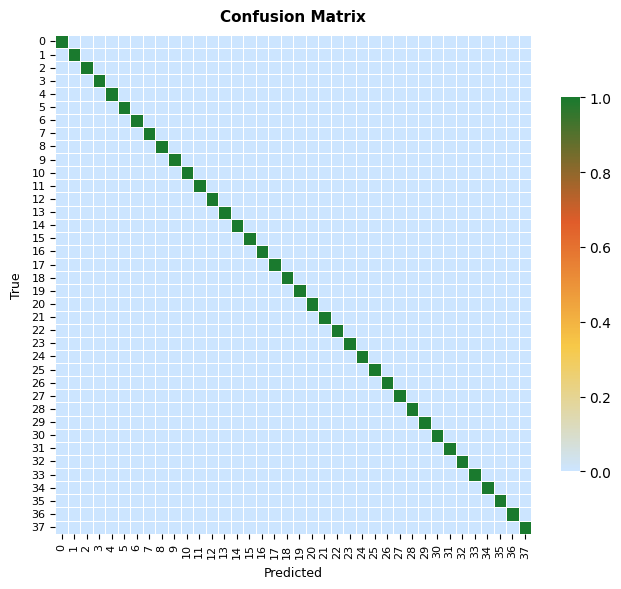


==================================== ROC CURVE ====================================


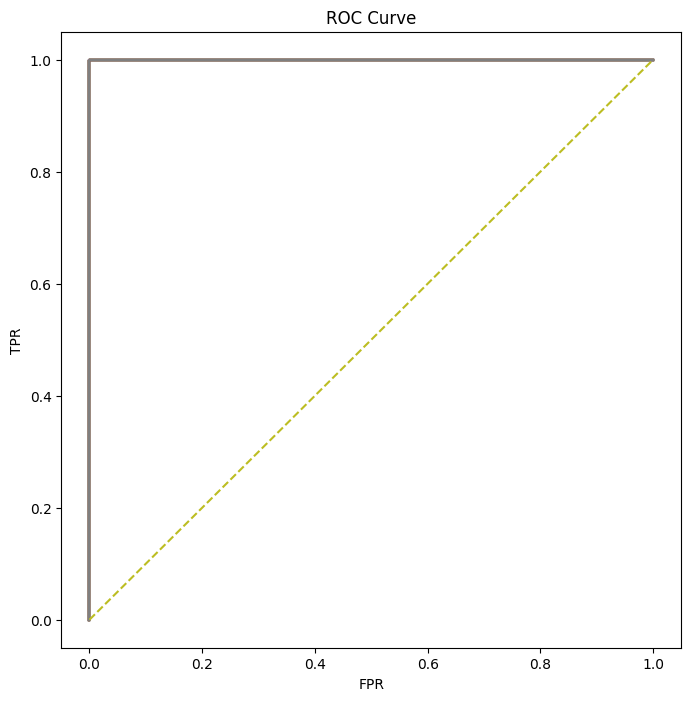

In [10]:
print("TRAINING DATA")
train_true, train_pred, train_proba = get_preds(train_loader)
train_metrics = evaluate(train_true, train_pred, train_proba)

VALIDATION DATA

===== METRICS =====


Metrics,Value
Accuracy,0.994064
Precision,0.993903
Recall,0.994035
F1_Score,0.993896
ROC_AUC,0.999979
Log_loss,0.073368



============================ CONFUSION MATRIX =============================


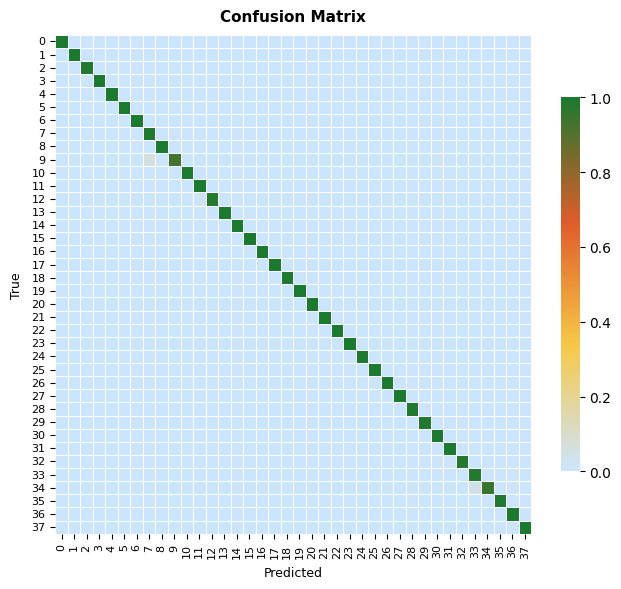


==================================== ROC CURVE ====================================


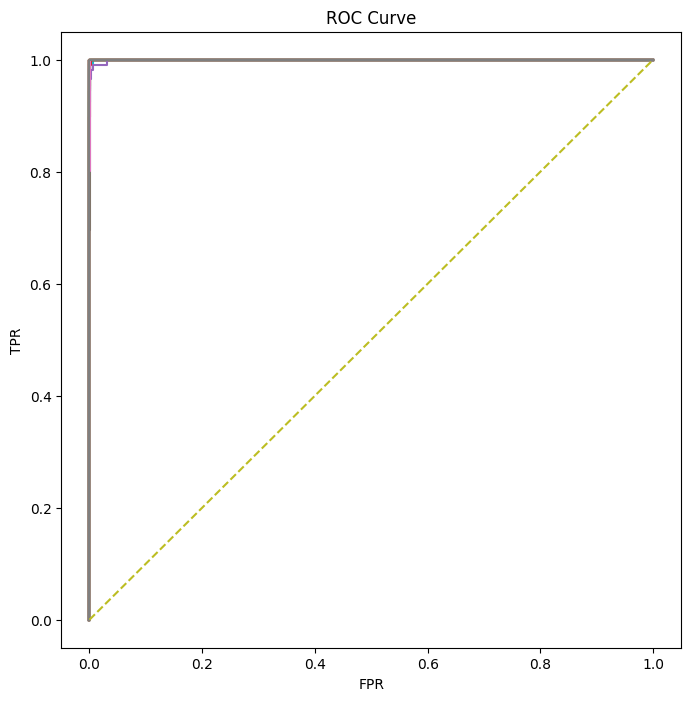

In [11]:
print("VALIDATION DATA")
val_true, val_pred, val_proba = get_preds(val_loader)
val_metrics = evaluate(val_true, val_pred, val_proba)

TESTING DATA

===== METRICS =====


Metrics,Value
Accuracy,0.994260
Precision,0.994163
Recall,0.994148
F1_Score,0.994151
ROC_AUC,0.999981
Log_loss,0.073419



============================ CONFUSION MATRIX =============================


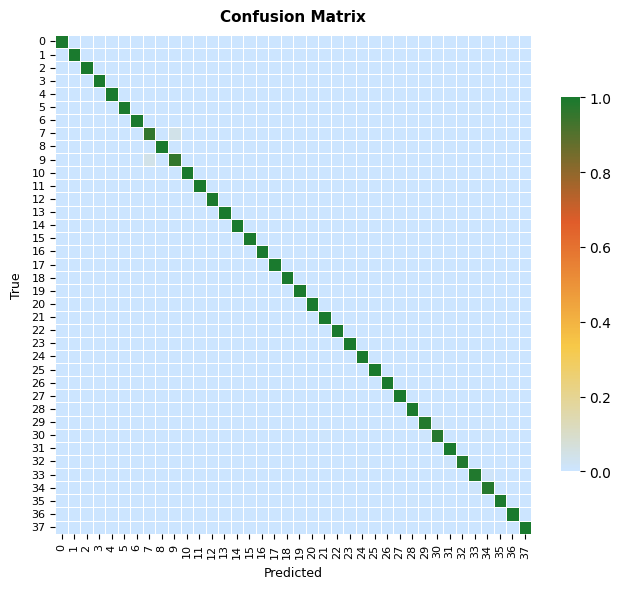


==================================== ROC CURVE ====================================


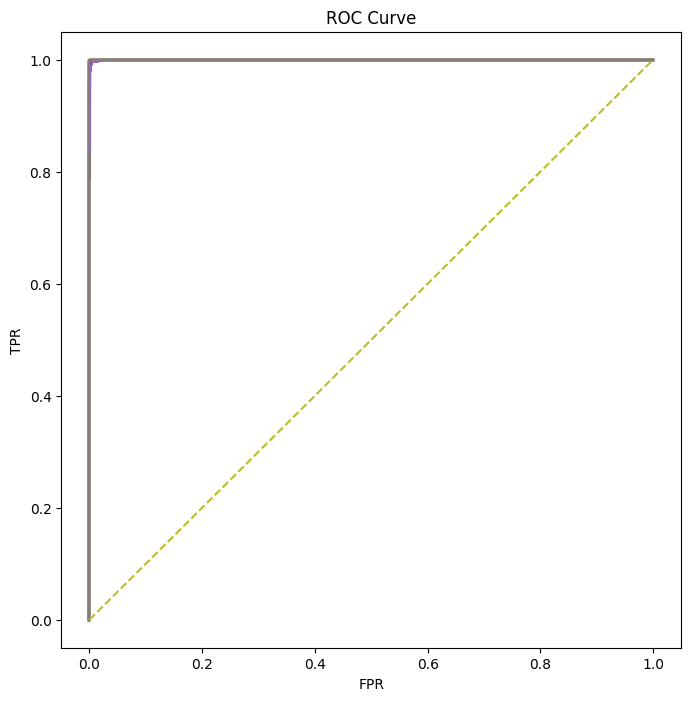

In [12]:
print("TESTING DATA")
test_true, test_pred, test_proba = get_preds(test_loader)
test_metrics = evaluate(test_true, test_pred, test_proba)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9998,0.9998,0.9999,0.9998,1.0000,0.0478
val,0.9941,0.9939,0.9940,0.9939,1.0000,0.0734
test,0.9943,0.9942,0.9941,0.9942,1.0000,0.0734


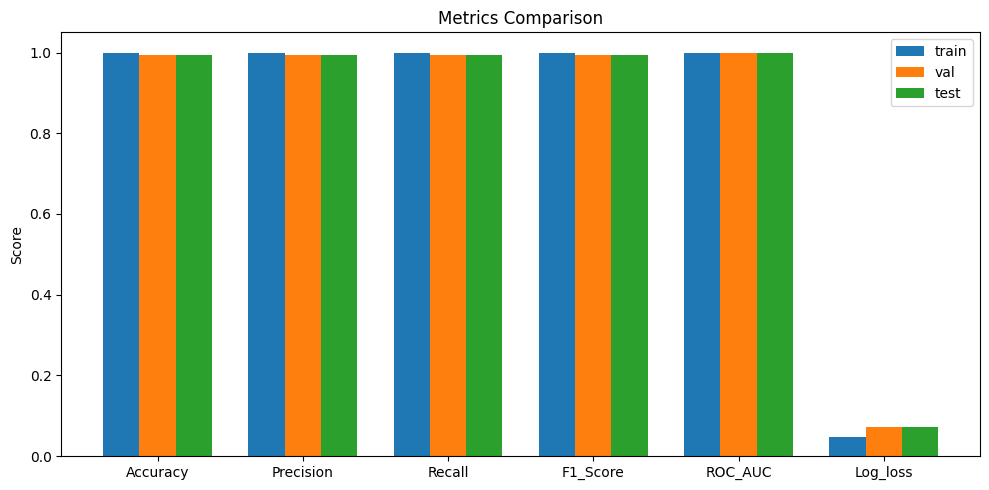

In [13]:
df_comparison = compare_splits(train_metrics, val_metrics, test_metrics)


# Feature Importance

Captured 138 attention tensors  (69 batches × 2 layers)
Each tensor shape: torch.Size([64, 4, 4])  (batch, tokens, tokens)

Per-block attention importance:
  GLCM           : 17.30%
  MobileNetV3    : 26.62%
  GoogLeNet      : 20.96%
  ConvNeXtSmall  : 35.13%


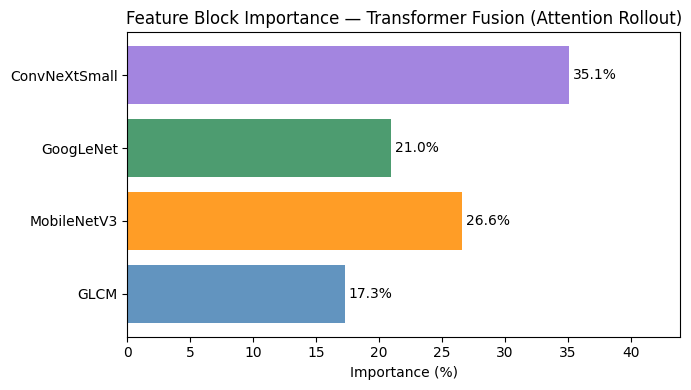

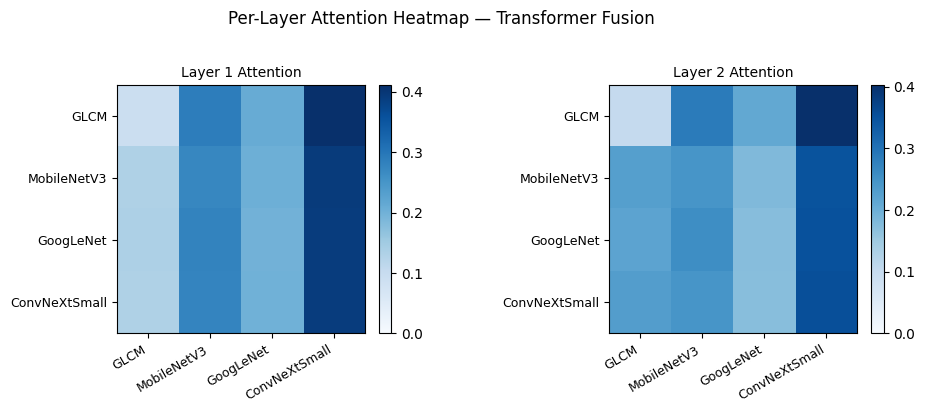

In [14]:
attn_weights_list = []

def _make_capturing_forward(l):
    def _forward(src, src_mask=None, src_key_padding_mask=None, is_causal=False):
        
        src2, attn_w = l.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=True,
        )
        if attn_w is not None:
            attn_weights_list.append(attn_w.detach().cpu())   

        src = l.norm1(src + l.dropout1(src2))
        src2 = l.linear2(l.dropout(l.activation(l.linear1(src))))
        src = l.norm2(src + l.dropout2(src2))
        return src
    return _forward

_original_forwards = []
for layer in model.transformer.layers:
    _original_forwards.append(layer.forward)
    layer.forward = _make_capturing_forward(layer)

model.eval()
attn_weights_list.clear()

with torch.no_grad():
    for *feats, y in val_loader:
        feats = [f.to(DEVICE) for f in feats]
        _ = model(*feats)

for layer, orig in zip(model.transformer.layers, _original_forwards):
    layer.forward = orig

num_layers  = N_LAYERS
num_tokens  = len(DIMS)
num_batches = len(val_loader)

print(f"Captured {len(attn_weights_list)} attention tensors  "
      f"({num_batches} batches × {num_layers} layers)")
print(f"Each tensor shape: {attn_weights_list[0].shape}  (batch, tokens, tokens)")

layer_attn = [[] for _ in range(num_layers)]
for i, attn in enumerate(attn_weights_list):
    layer_attn[i % num_layers].append(attn)

layer_attn_mean = []
for l in range(num_layers):
    stacked = torch.cat(layer_attn[l], dim=0)   
    layer_attn_mean.append(stacked.mean(dim=0))  

T = num_tokens
rollout = torch.eye(T)
for attn_mat in layer_attn_mean:
    attn_mat = 0.5 * attn_mat + 0.5 * torch.eye(T)         
    attn_mat = attn_mat / attn_mat.sum(dim=-1, keepdim=True) 
    rollout  = attn_mat @ rollout

token_importance = rollout.mean(dim=0).numpy()
token_importance = token_importance / token_importance.sum() * 100  
print("\nPer-block attention importance:")
for name, imp in zip(BLOCK_NAMES, token_importance):
    print(f"  {name:<15}: {imp:.2f}%")

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

plt.figure(figsize=(7, 4))
bars = plt.barh(BLOCK_NAMES, token_importance, color=colors, alpha=0.85)
plt.xlabel("Importance (%)")
plt.title("Feature Block Importance — Transformer Fusion (Attention Rollout)")
plt.xlim(0, max(token_importance) * 1.25)
for bar, val in zip(bars, token_importance):
    plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 4))
if num_layers == 1:
    axes = [axes]

for l, (ax, attn_mat) in enumerate(zip(axes, layer_attn_mean)):
    im = ax.imshow(attn_mat.numpy(), cmap="Blues", vmin=0)
    ax.set_xticks(range(T)); ax.set_xticklabels(BLOCK_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(T)); ax.set_yticklabels(BLOCK_NAMES, fontsize=9)
    ax.set_title(f"Layer {l+1} Attention", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Per-Layer Attention Heatmap — Transformer Fusion", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
